# Foreword

### Goal

The goal of this notebook is to find STEREO WAVES data and plot a spectrogram.

### Structure

1. Test 1: I downloaded custom cdf files (containing only the variable I am interested in) from the CDAWeb (on the webpage); then I opened the data with spacepy pyplot, and plotted both LFR and HFR spectra together using matplotlib pcolormesh.
2. Test 2: I downloaded the standard cdf files from CDAWeb using SunPy Fido, then open and plot the data as I did in test 1.
3. Test 3: I opened the standard cdf files (downloaded in test 2, from Fido) with maser4py, and use maser4py to plot the spectra.

### Set up

My conda environment is running with:
- Python 3.12.7
- maser-data 0.4.2
- maser-plot 0.3.3
- maser-tools 0.2.0
- maser4py 0.16.1
- sunpy 6.0.3
- sunpy-soar 1.11.1

# First test: manual download from CDAWeb

In [1]:
import numpy as np
from spacepy import pycdf
from sunpy.time import parse_time
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from matplotlib import ticker

In [2]:
myFmt = mdates.DateFormatter('%H:%M') 

## Find data

I found the data on the [CDAWeb page](https://cdaweb.gsfc.nasa.gov/), by selecting `STEREO` and `Radio and Plasma Waves (space)`.  
I then landed on a page with available data sets and selected `STA_L3_WAV_HFR` and `STA_L3_WAV_LFR`.  
I then selected the time range `2025/03/26 00:00:00.000` to `2025/03/27 00:00:00.000`, clicked on `Create V3.9 CDFs for download` and selected the following variable: `Power spectral density after 1% background subtraction and antenna calibration in solar radio flux unit normalized to 1 au` for both instruments.  
As a result I downloaded two files:
- sta_l3s_wav_lfr_20250326000005_20250326235935_cdaweb.cdf
- sta_l3s_wav_hfr_20250326000033_20250326235928_cdaweb.cdf

## Open data

### Read cdf files

In [3]:
cdaweb_hfr_file = '..\\..\\..\\Downloads\\sta_l3s_wav_hfr_20250326000033_20250326235928_cdaweb.cdf'
cdaweb_lfr_file = '..\\..\\..\\Downloads\\sta_l3s_wav_lfr_20250326000005_20250326235935_cdaweb.cdf'

In [4]:
cdaweb_hfr_data = pycdf.CDF(cdaweb_hfr_file)

In [5]:
cdaweb_lfr_data = pycdf.CDF(cdaweb_lfr_file)

### Explore content of HFR file

In [6]:
cdaweb_hfr_data

<CDF:
Epoch: CDF_TIME_TT2000 [2472]
FREQUENCY: CDF_FLOAT [319] NRV
PSD_SFU: CDF_FLOAT [2472, 319]
>

In [7]:
cdaweb_hfr_time = np.array(cdaweb_hfr_data['Epoch'])
cdaweb_hfr_frequency = np.array(cdaweb_hfr_data['FREQUENCY'])

Note: there is no attributes to the time and frequency in these custom files

In [8]:
cdaweb_hfr_frequency.attrs

AttributeError: 'numpy.ndarray' object has no attribute 'attrs'

We can still get information on the data

In [9]:
cdaweb_hfr_data['PSD_SFU'].attrs

<zAttrList:
CATDESC: Power spectral density after 1% background subtraction and antenna calibration in solar radio flux unit normalized to 1 au [CDF_CHAR]
DEPEND_0: Epoch [CDF_CHAR]
DEPEND_1: FREQUENCY [CDF_CHAR]
DIM_SIZES: 319 [CDF_INT4]
DISPLAY_TYPE: spectrogram [CDF_CHAR]
FIELDNAM: Power Spectral Density [CDF_CHAR]
FILLVAL: -1e+31 [CDF_FLOAT]
FORMAT: E12.2 [CDF_CHAR]
LABLAXIS: PSD [CDF_CHAR]
SCALETYP: log [CDF_CHAR]
UNITS: sfu [CDF_CHAR]
VALIDMAX: 1e+20 [CDF_FLOAT]
VALIDMIN: 0.0 [CDF_FLOAT]
VAR_NOTES: Suitable for multi-spacecraft investigation [CDF_CHAR]
VAR_TYPE: data [CDF_CHAR]
>

Print the first time bin duration to check cadence

In [10]:
print(cdaweb_hfr_time[1]-cdaweb_hfr_time[0])

0:00:34.941030


Print the min and max of the frequency data to "guess" the units

In [11]:
print(cdaweb_hfr_frequency.min())
print(cdaweb_hfr_frequency.max())

125000.0
16000000.0


The frequency is in Hz. Converting to MHz

In [12]:
cdaweb_hfr_frequency_MHz = cdaweb_hfr_frequency/1e6

### Similar with LFR

In [13]:
cdaweb_lfr_data

<CDF:
Epoch: CDF_TIME_TT2000 [2473]
FREQUENCY: CDF_FLOAT [48] NRV
PSD_SFU: CDF_FLOAT [2473, 48]
>

In [14]:
cdaweb_lfr_time = np.array(cdaweb_lfr_data['Epoch'])
cdaweb_lfr_frequency = np.array(cdaweb_lfr_data['FREQUENCY'])

In [15]:
print(cdaweb_lfr_frequency.min())
print(cdaweb_lfr_frequency.max())

2610.0
153000.0


In [16]:
cdaweb_lfr_frequency_MHz = cdaweb_lfr_frequency/1e6

## Plot dynamic spectra

### Plot the full spectra, combined in one plot

In [17]:
z_hfr = np.transpose(np.array(cdaweb_hfr_data['PSD_SFU']))
x_hfr, y_hfr = np.meshgrid(cdaweb_hfr_time, cdaweb_hfr_frequency_MHz)

In [18]:
z_lfr = np.transpose(np.array(cdaweb_lfr_data['PSD_SFU']))
x_lfr, y_lfr = np.meshgrid(cdaweb_lfr_time, cdaweb_lfr_frequency_MHz)

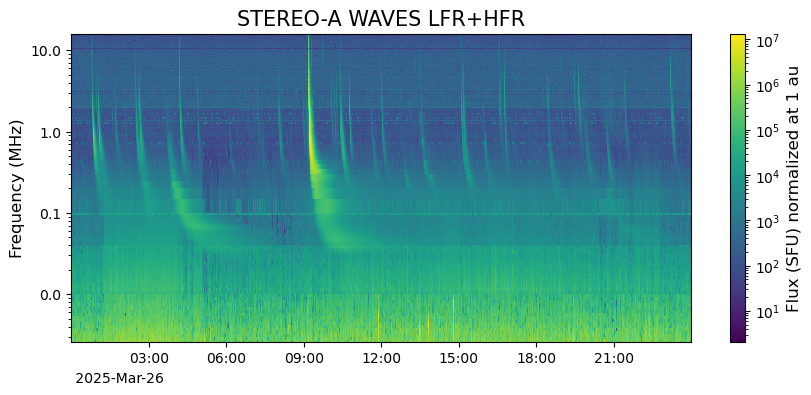

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

# Plot the data, make sure the color scale will be the same for both
vmin = z_lfr.min()
vmax = z_hfr.max()
c1 = ax.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin = vmin, vmax = vmax))
c2 = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin = vmin, vmax = vmax))   
ax.set_title('STEREO-A WAVES LFR+HFR', fontsize = 15)

# Format time axis
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel(" {:s}".format(cdaweb_hfr_time[0].strftime("%Y-%b-%d")), loc="left")

# Frequency axis
ax.set_ylabel('Frequency (MHz)', fontsize = 12)

# Set the limits of the plot to the limits of the data
ax.axis([x_lfr.min(), x_hfr.max(), y_lfr.min(), y_hfr.max()])
ax.set_yscale('log')

# Producing the colorbar
cb = plt.colorbar(c1)  
cb.set_label(label= 'Flux (SFU) normalized at 1 au', size = 12)

# scalar notation instead of scientific notation for labels on y axis - for some reason needs to be at the end of the code block
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.show()

### Plot a slice

In [20]:
freq_min = 0.02
freq_max = y_hfr.max()
time_min = parse_time('2025/03/26 09:00').to_datetime()
time_max = parse_time('2025/03/26 10:00').to_datetime()

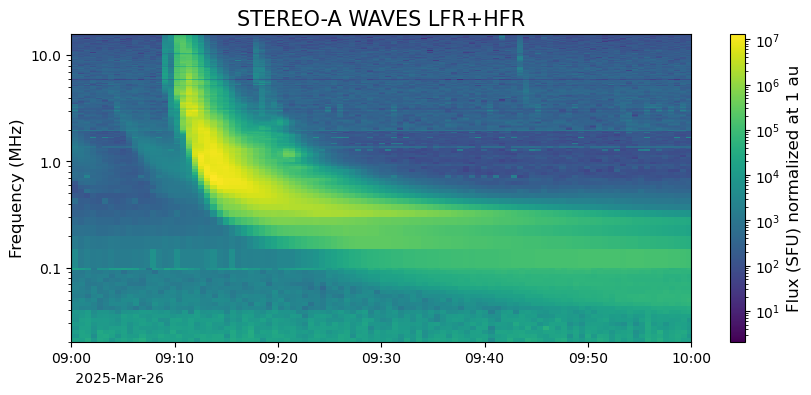

In [21]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

# Plot the data, make sure the color scale will be the same for both
vmin = z_lfr.min()
vmax = z_hfr.max()
c1 = ax.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin = vmin, vmax = vmax))
c2 = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin = vmin, vmax = vmax))   
ax.set_title('STEREO-A WAVES LFR+HFR', fontsize = 15)

# Format time axis
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel(" {:s}".format(cdaweb_hfr_time[0].strftime("%Y-%b-%d")), loc="left")

# Frequency axis
ax.set_ylabel('Frequency (MHz)', fontsize = 12)

# Set the limits of the plot to the limits of the data
ax.axis([time_min, time_max, freq_min, freq_max])
ax.set_yscale('log')

# Producing the colorbar
cb = plt.colorbar(c1)  
cb.set_label(label= 'Flux (SFU) normalized at 1 au', size = 12)

# scalar notation instead of scientific notation for labels on y axis - for some reason needs to be at the end of the code block
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.show()

# Second test: Download from CDAWeb using Fido

In [22]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries

## Find data and download

I am using the [following example](https://docs.sunpy.org/en/latest/generated/gallery/acquiring_data/search_cdaweb.html) in the SunPy gallery.

The main difficuly is to find the name of the Dataset, one can visualize all the names available with:

In [23]:
a.cdaweb.Dataset

Attribute Name,Client,Full Name,Description
a1_k0_mpa,CDAWEB,A1_K0_MPA,LANL 2001 Magnetospheric Plasma Analyzer Key Parameters - Mike Henderson (LANL)
a2_k0_mpa,CDAWEB,A2_K0_MPA,LANL 2002 Magnetospheric Plasma Analyzer Key Parameters - Mike Henderson (LANL)
ac_at_def,CDAWEB,AC_AT_DEF,"ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (C..."
ac_h0_mfi,CDAWEB,AC_H0_MFI,H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Ins...
ac_h0_swe,CDAWEB,AC_H0_SWE,ACE/SWEPAM Solar Wind Experiment 64-Second Level 2 Data - D. J. McComas (SWRI)
ac_h1_epm,CDAWEB,AC_H1_EPM,ACE/EPAM Solar Energetic Particle 5-Minute Level 2 Data - R. Gold (JHU/APL)
ac_h1_mfi,CDAWEB,AC_H1_MFI,H1 - ACE Magnetic Field 4-Minute Level 2 Data - N. Ness (Bartol Research Inst...
ac_h1_sis,CDAWEB,AC_H1_SIS,ACE/SIS Solar Isotope Spectrometer 256-sec Level 2 Data - E. C. Stone (Califo...
ac_h2_cris,CDAWEB,AC_H2_CRIS,ACE/CRIS Cosmic Ray Isotope Spectrometer 1-Hour Level 2 Data - E. C. Stone (C...
ac_h2_epm,CDAWEB,AC_H2_EPM,ACE/EPAM Solar Energetic Particle 1-Hour Level 2 Data - R. Gold (JHU/APL)


Now we know that we are looking for datasets called `STA_L3_WAV_LFR` and `STA_L3_WAV_HFR`.

In [24]:
trange = a.Time('2025/03/25', '2025/03/27')
dataset = a.cdaweb.Dataset('STA_L3_WAV_LFR')
result_lfr = Fido.search(trange, dataset)

In [25]:
result_lfr

Dataset,Start time,End time,URL
str14,str23,str23,str122
STA_L3_WAV_LFR,2025-03-25 00:00:00.000,2025-03-25 23:59:30.000,https://cdaweb.gsfc.nasa.gov/sp_phys/data/stereo/ahead/l3/waves/lfr-direction-finding/2025/sta_l3_wav_lfr_20250325_v01.cdf
STA_L3_WAV_LFR,2025-03-26 00:00:05.000,2025-03-26 23:59:35.000,https://cdaweb.gsfc.nasa.gov/sp_phys/data/stereo/ahead/l3/waves/lfr-direction-finding/2025/sta_l3_wav_lfr_20250326_v01.cdf


In [26]:
downloaded_files_lfr = Fido.fetch(result_lfr)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [27]:
fido_lfr_file = downloaded_files_lfr[1]

In [28]:
trange = a.Time('2025/03/25', '2025/03/27')
dataset = a.cdaweb.Dataset('STA_L3_WAV_HFR')
result_hfr = Fido.search(trange, dataset)

In [29]:
result_hfr

Dataset,Start time,End time,URL
str14,str23,str23,str122
STA_L3_WAV_HFR,2025-03-25 00:00:28.000,2025-03-25 23:59:58.000,https://cdaweb.gsfc.nasa.gov/sp_phys/data/stereo/ahead/l3/waves/hfr-direction-finding/2025/sta_l3_wav_hfr_20250325_v01.cdf
STA_L3_WAV_HFR,2025-03-26 00:00:33.000,2025-03-27 00:00:03.000,https://cdaweb.gsfc.nasa.gov/sp_phys/data/stereo/ahead/l3/waves/hfr-direction-finding/2025/sta_l3_wav_hfr_20250326_v01.cdf


In [30]:
downloaded_files_hfr = Fido.fetch(result_hfr)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [31]:
fido_hfr_file = downloaded_files_hfr[1]

## Open data

In [32]:
fido_lfr_data = pycdf.CDF(fido_lfr_file)

In [33]:
fido_hfr_data = pycdf.CDF(fido_hfr_file)

In [34]:
fido_lfr_psd_sfu = fido_lfr_data['PSD_SFU']
fido_lfr_freq = fido_lfr_data['FREQUENCY']
fido_lfr_time = fido_lfr_data['Epoch']

In [35]:
fido_hfr_psd_sfu = fido_hfr_data['PSD_SFU']
fido_hfr_freq = fido_hfr_data['FREQUENCY']
fido_hfr_time = fido_hfr_data['Epoch']

### Explore attributes

In [36]:
print(fido_lfr_psd_sfu.attrs)

CATDESC: Power spectral density after 1% background subtraction and antenna calibration in solar radio flux unit normalized to 1 au [CDF_CHAR]
DEPEND_0: Epoch [CDF_CHAR]
DEPEND_1: FREQUENCY [CDF_CHAR]
DISPLAY_TYPE: spectrogram [CDF_CHAR]
FIELDNAM: Power Spectral Density [CDF_CHAR]
FILLVAL: -1e+31 [CDF_REAL4]
FORMAT: E12.2 [CDF_CHAR]
LABLAXIS: PSD [CDF_CHAR]
SCALETYP: log [CDF_CHAR]
UNITS: sfu [CDF_CHAR]
VALIDMAX: 1e+20 [CDF_REAL4]
VALIDMIN: 0.0 [CDF_REAL4]
VAR_NOTES: Suitable for multi-spacecraft investigation [CDF_CHAR]
VAR_TYPE: data [CDF_CHAR]


In [37]:
print(fido_lfr_freq.attrs)

CATDESC: Frequency channel [CDF_CHAR]
FIELDNAM: Frequency [CDF_CHAR]
FILLVAL: -1e+31 [CDF_REAL4]
FORMAT: E12.2 [CDF_CHAR]
LABLAXIS: FREQUENCY [CDF_CHAR]
SCALETYP: log [CDF_CHAR]
UNITS: Hz [CDF_CHAR]
VALIDMAX: 16000000.0 [CDF_REAL4]
VALIDMIN: 1.0 [CDF_REAL4]
VAR_TYPE: support_data [CDF_CHAR]


In [38]:
print(fido_lfr_time.attrs)

CATDESC: Epoch encoded as Terrestrial Time on rotating Earth geoid, ns since J2000 [CDF_CHAR]
FIELDNAM: Epoch (Time) [CDF_CHAR]
FILLVAL: 9999-12-31 23:59:59.999999 [CDF_TIME_TT2000]
LABLAXIS: epoch_hfr_radio_flux [CDF_CHAR]
MONOTON: INCREASE [CDF_CHAR]
REFERENCE_POSITION: Rotating Earth Geoid [CDF_CHAR]
SCALETYP: linear [CDF_CHAR]
TIME_BASE: J2000 [CDF_CHAR]
TIME_SCALE: Terrestrial Time [CDF_CHAR]
UNITS: ns [CDF_CHAR]
VALIDMAX: 2099-12-31 23:59:59.999000 [CDF_TIME_TT2000]
VALIDMIN: 2006-01-01 00:00:00 [CDF_TIME_TT2000]
VAR_TYPE: support_data [CDF_CHAR]


## Plot data in the same way as before

### Plot full spectra

In [39]:
z_hfr = np.transpose(np.array(fido_hfr_psd_sfu))
x_hfr, y_hfr = np.meshgrid(np.array(fido_hfr_time), np.array(fido_hfr_freq)/1e6)

In [40]:
z_lfr = np.transpose(np.array(fido_lfr_psd_sfu))
x_lfr, y_lfr = np.meshgrid(np.array(fido_lfr_time), np.array(fido_lfr_freq)/1e6)

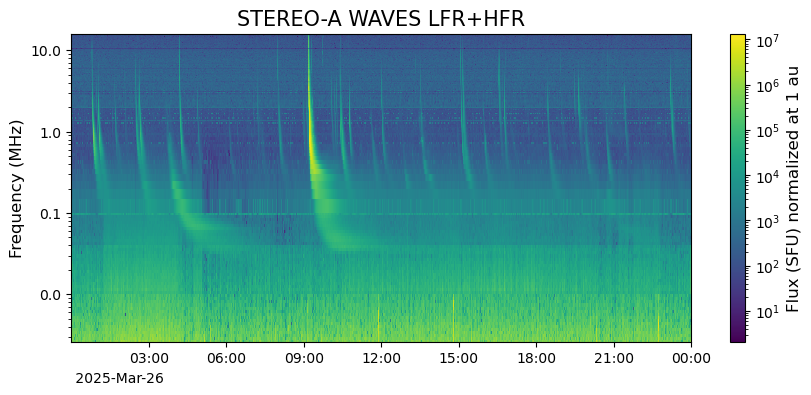

In [41]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

# Plot the data, make sure the color scale will be the same for both
vmin = z_lfr.min()
vmax = z_hfr.max()
c1 = ax.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin = vmin, vmax = vmax))
c2 = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin = vmin, vmax = vmax))   
ax.set_title('STEREO-A WAVES LFR+HFR', fontsize = 15)

# Format time axis
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel(" {:s}".format(cdaweb_hfr_time[0].strftime("%Y-%b-%d")), loc="left")

# Frequency axis
ax.set_ylabel('Frequency (MHz)', fontsize = 12)

# Set the limits of the plot to the limits of the data
ax.axis([x_lfr.min(), x_hfr.max(), y_lfr.min(), y_hfr.max()])
ax.set_yscale('log')

# Producing the colorbar
cb = plt.colorbar(c1)  
cb.set_label(label= 'Flux (SFU) normalized at 1 au', size = 12)

# scalar notation instead of scientific notation for labels on y axis - for some reason needs to be at the end of the code block
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.show()

# Third test: Plotting with Maser4py

I followed, to start with, the maser4py [tutorial](https://gitlab.obspm.fr/maser/maser4py/-/blob/fix_install/docs/source/sections/tutorial.rst?ref_type=heads).

In [70]:
from maser.data import Data
import xarray

## Open data

### Loading data from previously downloaded files

In [43]:
maser_data_hfr = Data(fido_hfr_file)

In [44]:
maser_data_lfr = Data(fido_lfr_file)

### Explore data

In [47]:
xs = maser_data_hfr.as_xarray()

In [48]:
xs.attrs

{}

In [49]:
xd = xs["PSD_SFU"]

In [50]:
xd.attrs

{'units': 'sfu'}

## Plot

### Plot one spectrum

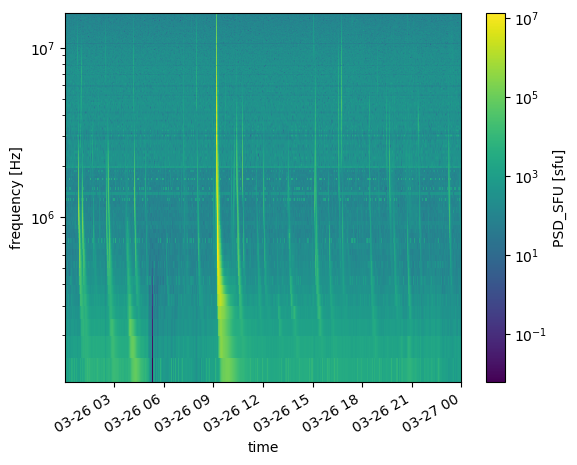

In [51]:
xs = maser_data_hfr.as_xarray()
xd = xs["PSD_SFU"]
xd.attrs["units"] = xd.attrs['units']
xd.plot(yscale="log", norm=LogNorm())
plt.show()

### Plotting in a subplot

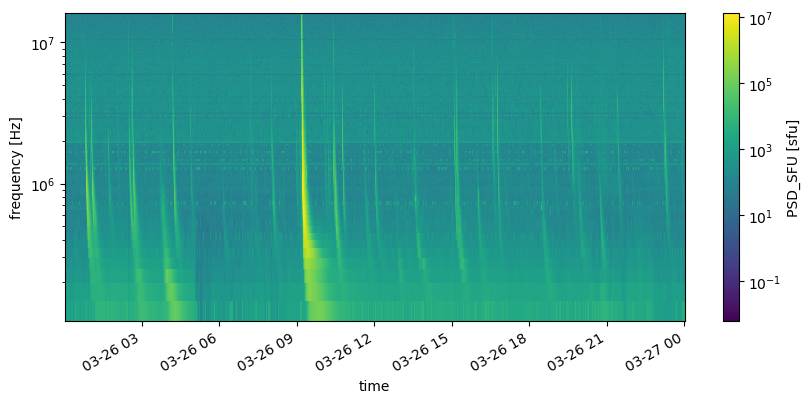

In [53]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
xs = maser_data_hfr.as_xarray()
xd = xs["PSD_SFU"]
xd.attrs["units"] = xd.attrs['units']
xd.plot(yscale="log", norm=LogNorm(), ax=ax)
plt.show()

### Slicing

In [65]:
freq_min = 0.1e6
freq_max = 2e7
time_min = parse_time('2025/03/26 09:00').to_datetime()
time_max = parse_time('2025/03/26 10:00').to_datetime()

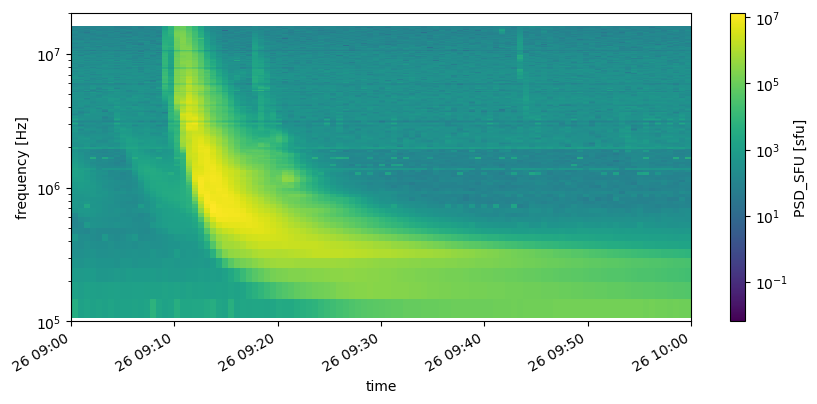

In [66]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
xs = maser_data_hfr.as_xarray()
xd = xs["PSD_SFU"]
xd.attrs["units"] = xd.attrs['units']
xd.plot(yscale="log", norm=LogNorm(), ax=ax)
ax.axis([time_min, time_max, freq_min, freq_max])
plt.show()

### DOES NOT WORK: Plot combined spectra by concatenating data

Concatenate data

In [71]:
concat_ar = xarray.concat([maser_data_lfr.as_xarray(), maser_data_hfr.as_xarray()], dim="frequency")

C:\Users\mussesm1.SDSCI\AppData\Local\miniconda3\envs\stixmaserenv\Lib\site-packages\xarray\core\concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


Need to sort the data

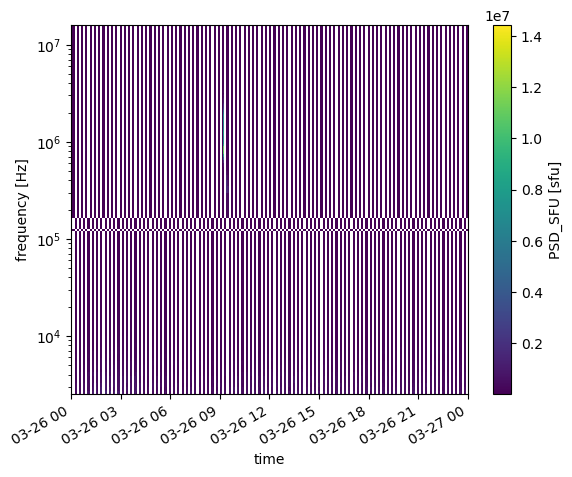

In [73]:
concat_ar["PSD_SFU"].sortby("time").sortby("frequency").plot(cmap="viridis", yscale="log")

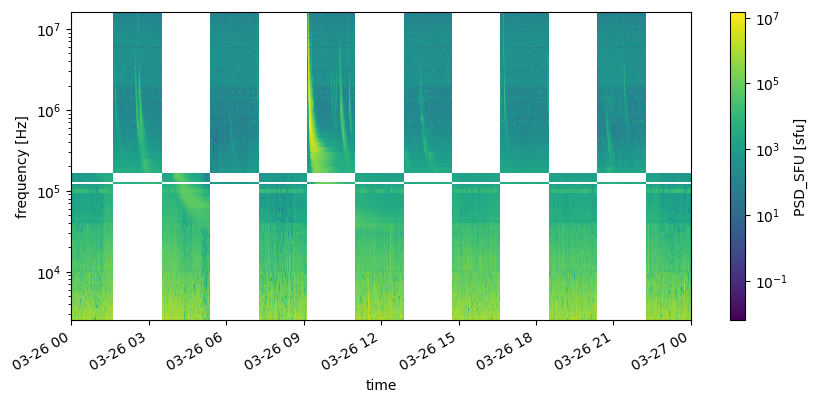

In [78]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
xd = concat_ar["PSD_SFU"].sortby("frequency").sortby("time")
xd.attrs["units"] = xd.attrs['units']
xd.plot(yscale="log", norm=LogNorm(), ax=ax)
plt.show()

### Do not concatenate: plot spectra together one by one

In [80]:
xhfr = maser_data_hfr.as_xarray()
xlfr = maser_data_lfr.as_xarray()

In [107]:
z_lfr = np.transpose(np.array(xlfr["PSD_SFU"]))
z_lfr = np.array(xlfr["PSD_SFU"])
x_lfr, y_lfr = np.meshgrid(np.array(xlfr["time"]), np.array(xlfr["frequency"]))

In [109]:
z_hfr = np.transpose(np.array(xhfr["PSD_SFU"]))
z_hfr = np.array(xhfr["PSD_SFU"])
x_hfr, y_hfr = np.meshgrid(np.array(xhfr["time"]), np.array(xhfr["frequency"]))

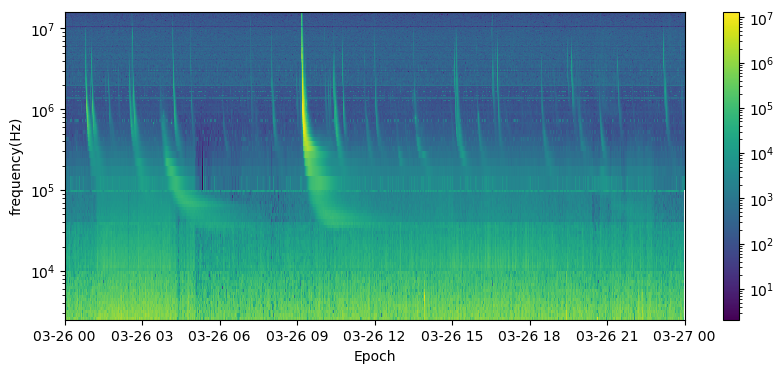

In [111]:
plt.figure(figsize = (10, 4))
#plt.pcolormesh(xhfr["time"], xhfr["frequency"], xhfr["PSD_SFU"], cmap="viridis")

vmin = z_lfr.min()
vmax = z_hfr.max()
plt.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin = vmin, vmax = vmax))
plt.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin = vmin, vmax = vmax)) 
plt.yscale("log")
#plt.pcolormesh(xlfr["time"], xlfr["frequency"], xlfr["PSD_SFU"], cmap="viridis")
plt.xlabel("Epoch")
plt.ylabel("frequency(Hz)")
plt.colorbar()
plt.show()